<h1> Detecting, flagging, and classifying pollution events</h1>

<p>Let's start by reading in our sample black carbon data and configuration file.</p>

In [1]:
import airinsights as air
import warnings
warnings.filterwarnings("ignore")

input_data, config = air.read_aqdata_file(input_file="sample_data/oakland_2017_100x100_blackcarbon.csv",
                                          config_file="../config/100x100_config.yaml")

Timestamp already in local timezone: America/Los_Angeles


The <code>pollution_events()</code> function calculates the median, median absolute deviation (MAD), and modified Z-score for each monitor by hour of day
to compare individual monitor observations to the monitor's historic observations at each hour of day. It flags readings that are elevated (Z-score >= 2) compared to this historical baseline.

The function then groups identified pollution events into more interpretable 'Regional' and 'Local' events based on distance and time. This is useful for distinguishing widespread pollution events (e.g. wildfire smoke) from more localized sources (e.g. railyards or construction sites). 

<small><code>help(air.pollution_events)</code> for more detail on the methodology.</small>

In [2]:
# Returns summary of events, and flagged dataframe of individual measurements
events, measurements = air.pollution_events(input_data, config)

# Join the event flags back to the original dataframe 
measurements = input_data.merge(measurements,
                  on = [config['site_col'],
                        config['timestamp_col'],
                        config['pollutant_col']],
                  how = "left")

The function returns two dataframes:
<br>
&emsp;1.<b> events</b> - A pandas DataFrame with one row per classified pollution event and the following columns:
<ul>
    <li>event_ID: unique identifier for the event, prefixed by scale and pollutant (e.g. "REG_PM2.5_0", "LOC_PM2.5_3") </li>
    <li>pollutant: pollutant name </li>
    <li>start_time, end_time: start and end times of the pollution event </li>
    <li>duration_hours: duration of the pollution event </li>
    <li>event_scale: "Regional", "Local", or "Unknown" if only a single monitor was involved </li>
    <li>sites: "Network-wide" for Regional events, or a comma-separated list of sites for Local and Unknown events </li>
    <li>peak_value: maximum measured value observed during the event </li>
    <li>typical_at_peak: the network's (Regional) or site's (Local) typical value for the peak's hour of day, for comparison against peak_value </li>
</ul>

In [35]:
# Sample of the summary data
events.sample(5)

,event_ID,pollutant,start_time,end_time,duration_hours,scale,sites,peak_value,typical_at_peak
204,REG_hourly_BC_3,hourly_BC,2017-08-04 15:00:00-07:00,2017-08-04 15:00:00-07:00,1.0,Regional,Network-wide,1.44,0.497487
91,LOC_hourly_BC_180,hourly_BC,2017-08-19 15:00:00-07:00,2017-08-19 16:00:00-07:00,2.0,Local,26,2.93,0.679706
45,LOC_hourly_BC_139,hourly_BC,2017-08-05 11:00:00-07:00,2017-08-05 11:00:00-07:00,1.0,Local,47,1.08,0.589661
7,LOC_hourly_BC_104,hourly_BC,2017-07-26 20:00:00-07:00,2017-07-26 20:00:00-07:00,1.0,Local,75,2.14,0.560000
126,LOC_hourly_BC_31,hourly_BC,2017-07-11 00:00:00-07:00,2017-07-11 00:00:00-07:00,1.0,Local,56,1.39,0.530000


&emsp; 2. <b>measurements</b> - The input DataFrame with the following columns appended:
<ul>
    <li>days_captured: number of days with data captured in the historical window</li>
    <li>site_typical : measurement median for hour of day over historical window </li>
    <li>site_z : modified Z-score of the AQ measurement calculated using MAD over historical window </li>
    <li>elevated_flag : severity of elevated measurement based on site_z. A Z-score greater than 2 is "Unusually high", a Z-score greater than 3 is "Extremely high". Z-scores below 2 are returned as NULL.  "Insufficient number of days captured" is returned if window size was insufficient to calculate a Z-score</li>
    <li>n_sites : number of monitoring sites with a valid z_score at that timestamp (used for network_z)</li>
    <li>network_z : network-wide median z-score at that timestamp </li>
    <li>local_z : the site's z-score, adjusted for the network z-score (local_z = site_z - network_z)</li>
    <li>network_value : network-wide median measured value at that timestamp </li>
    <li>network_typical : network-wide median of each site's typical value for that hour of day </li>
    <li>event_ID : list of pollution event_ID's associated with that site/timestamp.</li>
</ul>

In [36]:
# Sample of the classify_pollution_events returned df
measurements.sample(5)

,Unnamed: 0,Datetime,Site,Latitude,Longitude,pollutant,value,hour,days_captured,site_typical,site_z,elevated_flag,n_sites,network_z,local_z,network_value,network_typical,event_ID
42316,42316,2017-07-21 04:00:00-07:00,18,37.82455,-122.27947,hourly_BC,0.08,4.0,47.0,0.200000,-1.434666,NaN,82.0,-0.381001,-1.053665,0.230,0.270000,NaN
153418,153418,2017-08-19 10:00:00-07:00,64,37.81360,-122.29676,hourly_BC,0.89,10.0,58.0,0.559643,0.651222,NaN,60.0,-0.082564,0.733787,0.500,0.550000,NaN
86694,86694,2017-05-31 06:00:00-07:00,37,37.82239,-122.27235,hourly_BC,0.42,6.0,13.0,NaN,NaN,Insufficient number of days captured,0.0,NaN,NaN,0.855,NaN,NaN
198214,198214,2017-07-16 22:00:00-07:00,83,37.80992,-122.28392,hourly_BC,0.78,22.0,53.0,0.310000,2.049402,Unusually high,78.0,1.339859,0.709542,0.900,0.399937,NaN
24046,24046,2017-05-20 22:00:00-07:00,11,37.81689,-122.28157,hourly_BC,0.84,22.0,2.0,NaN,NaN,Insufficient number of days captured,0.0,NaN,NaN,0.880,NaN,NaN


<h3>Filtering events by classification</h3>

The event_ID column stores events as a list, because local and regional events can be flagged at the same time. This occurs when a sensor or cluster of sensors are signficantly elevated beyond the significantly elevated network median.<br>If we explode the event_ID column and merge back with the input data, we can retrieve hourly values and filter by event.

In [37]:
measurements = measurements.explode("event_ID")
measurements.sample(5)

,Unnamed: 0,Datetime,Site,Latitude,Longitude,pollutant,value,hour,days_captured,site_typical,site_z,elevated_flag,n_sites,network_z,local_z,network_value,network_typical,event_ID
66989,66989,2017-08-18 05:00:00-07:00,28,37.81193,-122.27695,hourly_BC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25328,25328,2017-07-13 08:00:00-07:00,11,37.81689,-122.28157,hourly_BC,0.52,8.0,54.0,0.409878,0.325635,NaN,72.0,0.405118,-0.079484,0.790,0.525,NaN
45707,45707,2017-05-23 11:00:00-07:00,20,37.80361,-122.29789,hourly_BC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
107845,107845,2017-08-20 13:00:00-07:00,45,37.80566,-122.28410,hourly_BC,0.25,13.0,56.0,0.490000,-1.348982,NaN,54.0,-0.632364,-0.716617,0.395,0.510,NaN
114886,114886,2017-08-13 22:00:00-07:00,48,37.81181,-122.28968,hourly_BC,0.24,22.0,60.0,0.424735,-0.924021,NaN,63.0,-0.822166,-0.101854,0.280,0.460,NaN


<h4>Local events only</h4>

In [38]:
local_events = measurements[measurements["event_ID"].str.contains("LOC")]
n_local_events = local_events["event_ID"].nunique()
print(f"Total number of identified local pollution events: {n_local_events}")
local_events.sample(5)

Total number of identified local pollution events: 201


,Unnamed: 0,Datetime,Site,Latitude,Longitude,pollutant,value,hour,days_captured,site_typical,site_z,elevated_flag,n_sites,network_z,local_z,network_value,network_typical,event_ID
200704,200704,2017-07-20 16:00:00-07:00,84,37.81558,-122.29449,hourly_BC,1.05,16.0,55.0,0.490000,2.021980,Unusually high,81.0,-0.090259,2.112239,0.44,0.440000,LOC_hourly_BC_69
176594,176594,2017-07-16 02:00:00-07:00,74,37.81765,-122.27722,hourly_BC,1.28,2.0,55.0,0.220000,4.606811,Extremely high,81.0,2.595034,2.011778,1.03,0.260000,LOC_hourly_BC_47
3890,3890,2017-07-20 02:00:00-07:00,2,37.80324,-122.29475,hourly_BC,1.17,2.0,57.0,0.370000,1.980684,NaN,82.0,-0.061278,2.041962,0.27,0.260000,LOC_hourly_BC_67
16268,16268,2017-08-04 20:00:00-07:00,7,37.81069,-122.29884,hourly_BC,1.32,20.0,50.0,0.489898,3.103876,Extremely high,64.0,1.042418,2.061459,0.82,0.489949,LOC_hourly_BC_136
181117,181117,2017-07-04 13:00:00-07:00,76,37.82383,-122.28323,hourly_BC,1.34,13.0,47.0,0.390000,3.173104,Extremely high,34.0,-0.830945,4.004049,0.24,0.420000,LOC_hourly_BC_9


<h4>Regional events only</h4>

In [39]:
regional_events = measurements[measurements["event_ID"].str.contains("REG")]
n_regional_events = regional_events["event_ID"].nunique()
print(f"Total number of identified regional pollution events: {n_regional_events}")
regional_events.sample(5)

Total number of identified regional pollution events: 4


,Unnamed: 0,Datetime,Site,Latitude,Longitude,pollutant,value,hour,days_captured,site_typical,site_z,elevated_flag,n_sites,network_z,local_z,network_value,network_typical,event_ID
126632,126632,2017-08-03 08:00:00-07:00,53,37.80390,-122.28785,hourly_BC,2.42,8.0,57.0,0.840000,1.663637,NaN,67.0,2.225024,-0.561387,2.16,0.574804,REG_hourly_BC_2
162635,162635,2017-08-03 11:00:00-07:00,68,37.82269,-122.28609,hourly_BC,1.26,11.0,57.0,0.480000,1.887650,NaN,68.0,2.007858,-0.120208,1.93,0.519976,REG_hourly_BC_2
131435,131435,2017-08-03 11:00:00-07:00,55,37.82157,-122.28162,hourly_BC,1.65,11.0,57.0,0.570000,2.024194,Unusually high,68.0,2.007858,0.016336,1.93,0.519976,REG_hourly_BC_2
25831,25831,2017-08-03 07:00:00-07:00,11,37.81689,-122.28157,hourly_BC,1.79,7.0,58.0,0.454973,2.495604,Unusually high,66.0,2.249636,0.245969,1.99,0.519811,REG_hourly_BC_2
214780,214780,2017-07-07 04:00:00-07:00,90,37.81249,-122.31145,hourly_BC,0.90,4.0,27.0,NaN,NaN,Insufficient number of days captured,66.0,2.098288,NaN,0.90,0.265000,REG_hourly_BC_0


<h4>Local events coinciding with regional events</h4>

In [40]:
local_events_during_regional_events = local_events.merge(regional_events.loc[:,["Site", "Datetime"]])
n_local_events_during_regional_events = local_events_during_regional_events["event_ID"].nunique()
print(f"Total number of identified local pollution events during a regional pollution event: {n_local_events_during_regional_events}")
local_events_during_regional_events.sample(5)

Total number of identified local pollution events during a regional pollution event: 2


,Unnamed: 0,Datetime,Site,Latitude,Longitude,pollutant,value,hour,days_captured,site_typical,site_z,elevated_flag,n_sites,network_z,local_z,network_value,network_typical,event_ID
5,176594,2017-07-16 02:00:00-07:00,74,37.81765,-122.27722,hourly_BC,1.28,2.0,55.0,0.220000,4.606811,Extremely high,81.0,2.595034,2.011778,1.03,0.26,LOC_hourly_BC_47
4,128405,2017-07-08 05:00:00-07:00,54,37.80695,-122.28928,hourly_BC,2.80,5.0,47.0,0.390000,4.621682,Extremely high,71.0,2.535855,2.085827,1.25,0.31,LOC_hourly_BC_20
1,51793,2017-07-16 01:00:00-07:00,22,37.82221,-122.27932,hourly_BC,2.14,1.0,59.0,0.190000,5.348404,Extremely high,78.0,2.220789,3.127615,0.93,0.26,LOC_hourly_BC_47
0,18005,2017-07-08 05:00:00-07:00,8,37.80822,-122.28739,hourly_BC,2.89,5.0,50.0,0.340000,4.734458,Extremely high,71.0,2.535855,2.198603,1.25,0.31,LOC_hourly_BC_20
3,63605,2017-07-08 05:00:00-07:00,27,37.80790,-122.28898,hourly_BC,2.77,5.0,50.0,0.324962,5.511481,Extremely high,71.0,2.535855,2.975626,1.25,0.31,LOC_hourly_BC_20


<h3>Visualizing flagged events</h3>

<h4>Local events</h4>

Let's take a closer look at the "LOC_hourly_BC_94" event from our sample output above.

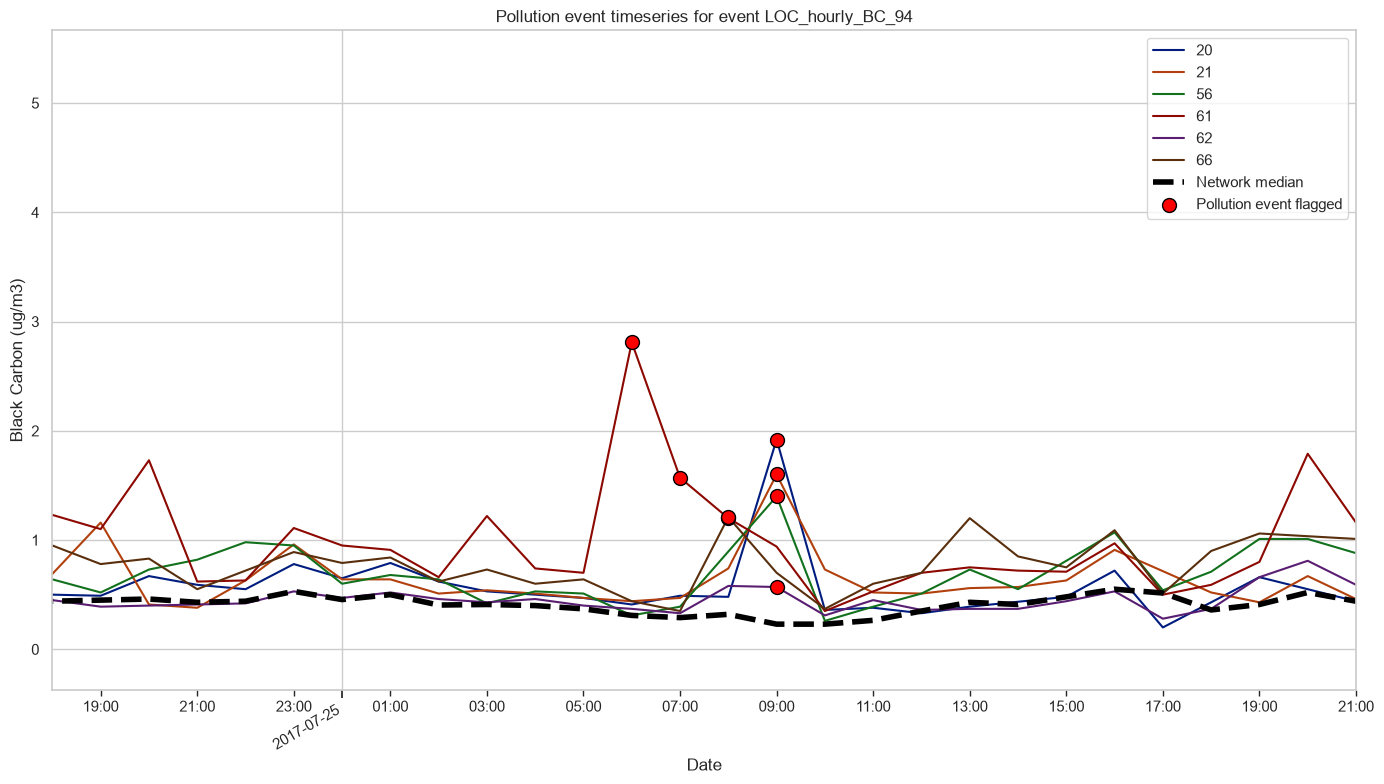

In [41]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta

event_of_interest = "LOC_hourly_BC_94"
event_to_plot = local_events[local_events["event_ID"]==event_of_interest]

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 8))

# Filter for sites matching our event of interest
event_sites = measurements[measurements["event_ID"]==event_of_interest]["Site"].unique()
event_hours = measurements[measurements["event_ID"]==event_of_interest]
# Return a single value per hour to plot the network median
network_median = measurements.groupby("Datetime")["network_value"].first().reset_index()

# Plot values for a sensor if it was involved in the event of interest
sns.lineplot(
    data=measurements[measurements["Site"].isin(event_sites)],
    x="Datetime",
    y="value",
    hue="Site",
    palette="dark",
    alpha=1.0,
    linewidth=1.5,
    ax=ax
)
# Plot the network median
sns.lineplot(
    data=network_median,
    x="Datetime",
    y="network_value",
    color="black",
    alpha=1,
    linewidth=4,
    linestyle="--",
    label="Network median",
    ax=ax
)
# Add a red circle onto hours flagged in the event
sns.scatterplot(
    data=event_hours,
    x="Datetime",
    y="value",
    color="red",
    edgecolor="black",
    s=100,
    linewidth=1,
    label="Pollution event flagged",
    legend=True,
    zorder=5,
    ax=ax
)

# Format labels
plt.title(f"Pollution event timeseries for event {event_of_interest}")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Black Carbon (ug/m3)", fontsize=12)
# Find event start, midpoint, and end times
event_start_time = event_to_plot["Datetime"].min()
event_end_time = event_to_plot["Datetime"].max()
event_midpoint = event_start_time + (event_end_time - event_start_time) / 2
# Format major ticks to occur daily
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
# Format minor ticks to occur every 3 hours
ax.tick_params(axis="x", which="both", bottom=True)
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%H:%M'))
# Set x-axis limits to roughly the day around the event
ax.set_xlim(event_start_time - timedelta(hours=12), event_end_time + timedelta(hours=12))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

<h4>Regional events</h4>

Let's look at the first regional event, "REG_hourly_BC_0", and the week surrounding it.

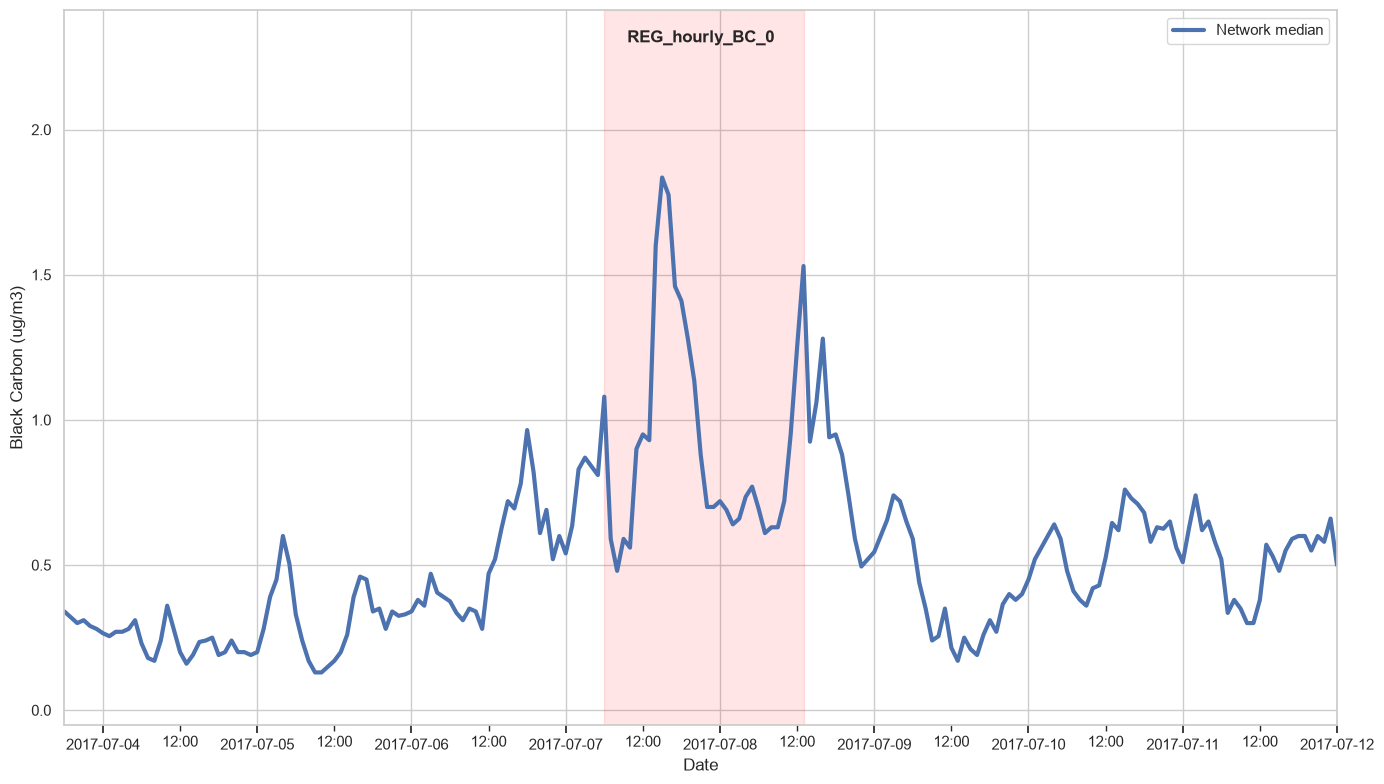

In [42]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import timedelta

event_of_interest = "REG_hourly_BC_0"

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 8))

# Plot the regional median value
sns.lineplot(
    data=network_median,
    x="Datetime",
    y="network_value",
    linewidth=3,
    label="Network median",
    ax=ax
)

# Filter data and find event start, midpoint, and end times
event_to_plot = regional_events[regional_events["event_ID"]==event_of_interest]
event_start_time = event_to_plot["Datetime"].min()
event_end_time = event_to_plot["Datetime"].max()
event_midpoint = event_start_time + (event_end_time - event_start_time) / 2

# Shade the regional event times in red 
ax.axvspan(event_start_time,
           event_end_time + timedelta(hours=1),
           color="red",
           alpha=0.1,
           label=event_of_interest)

# Place the event ID in the shaded area near the top of the figure 
event_text_y = ax.get_ylim()[1] * 0.96
ax.text(x=event_midpoint,
        y=event_text_y,
        s=event_of_interest,
        horizontalalignment='center', 
        verticalalignment='center',
        fontweight='bold')

# Format labels
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Black Carbon (ug/m3)", fontsize=12)
# Format major ticks to occur daily
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
# Format minor ticks to occur every 12 hours
ax.tick_params(axis="x", which="both", bottom=True)
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=12))
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%H:%M'))
# Set x-axis limits to the week around the event
ax.set_xlim(event_start_time - timedelta(days=3, hours=12), event_end_time + timedelta(days=3, hours=12))

plt.tight_layout()
plt.show()